# Where an utterance sits in Whisper's 30 s window vs. corpus WER

Whisper always encodes a fixed **30 s** input. A 3 s utterance therefore occupies ~10 % of the
window and the other ~90 % is padding. This notebook asks whether **position** inside that
window changes the transcript, holding the audio bit-identical and moving only *where* it sits.

**Design.** 1000 short TIMIT `TEST` utterances x 6 offsets (0, 5, 10, 15, 20, 25 s) x 2 arms
(timestamp tokens on / off) = **12 000 decodes**. We report *corpus* WER per offset and plot the
two arms separately.

Every offset is an integer multiple of `HOP_LENGTH = 160` samples, so a shift of the audio is
exactly a shift of the mel frames - verified in section 4 before any decoding happens.

## 1. Imports and the control register

Everything that could vary between runs is pinned here and printed into the output, so the
notebook documents its own configuration.

`whisper.decode()` is used rather than `model.transcribe()`. `transcribe()` wraps the decoder in
a seek loop plus `no_speech_threshold=0.6`, `logprob_threshold=-1.0` and
`compression_ratio_threshold=2.4`; any of those can blank or re-roll a segment in an
*offset-dependent* way, which is exactly the effect we are trying to measure. `decode()` is one
encoder pass and one greedy decode per (file, offset) and nothing else. It also accepts a batched
mel `(B, 80, 3000)`, which is what makes a 12 000-cell grid affordable.

Two of the requested controls have no direct argument on `decode()` and map onto it like this:

| requested | `whisper.decode()` equivalent |
|---|---|
| `condition_on_previous_text=False` | `prompt=None` - no `<\|startofprev\|>` block is emitted |
| `initial_prompt=""` | `prompt=None` / `prefix=None` - the token sequence starts at `<\|startoftranscript\|>` |

In [1]:
import collections, csv, glob, json, os, random, time

import numpy as np
import torch
import soundfile as sf
import whisper
from whisper.audio import log_mel_spectrogram, N_SAMPLES, SAMPLE_RATE, HOP_LENGTH
from whisper.normalizers import EnglishTextNormalizer
from whisper.tokenizer import get_tokenizer
from jiwer import process_words

TIMIT_TEST   = "/Users/agrfhyl/Documents/timit/TIMIT/TEST"
MANIFEST     = "offset_manifest.json"
RESULTS_CSV  = "offset_results.csv"

OFFSETS_S    = [0, 5, 10, 15, 20, 25]                     # seconds
OFFSETS      = [s * SAMPLE_RATE for s in OFFSETS_S]       # samples
ARMS         = [True, False]                              # timestamps on / off

CONTROLS = {
    "model":                  "base",
    "device":                 "mps" if torch.backends.mps.is_available() else "cpu",
    "batch_size":             16,
    "fp16":                   False,                # fp32 everywhere
    "mel_device":             "cpu",                # mel always CPU fp32
    "n_mels":                 80,
    "task":                   "transcribe",
    "language":               "en",
    "temperature":            0.0,                  # greedy
    "beam_size":              None,
    "best_of":                None,
    "prompt":                 None,                 # == condition_on_previous_text=False
    "prefix":                 None,                 # == initial_prompt=""
    "suppress_blank":         True,                 # stock
    "suppress_tokens":        "-1",                 # stock
    "max_initial_timestamp":  1.0,                  # stock -- see section 5 caveat
    "padding":                "zeros only (np.zeros(480000, float32))",
    "offsets_s":              OFFSETS_S,
    "hop_length":             HOP_LENGTH,
    "normalizer":             "whisper EnglishTextNormalizer (applied to BOTH ref and hyp)",
    "wer":                    "corpus-level: pooled S+D+I over pooled reference length",
    "selection_seed":         0,
}

# every offset must be an exact multiple of the STFT hop, or a shift of the audio is not a
# shift of the mel and the whole comparison is invalid
for s, n in zip(OFFSETS_S, OFFSETS):
    assert n % HOP_LENGTH == 0, f"offset {s}s = {n} samples is not a multiple of {HOP_LENGTH}"

print(f"whisper {whisper.__version__} | torch {torch.__version__}")
for k, v in CONTROLS.items():
    print(f"  {k:24s} {v}")

whisper 20250625 | torch 2.13.0
  model                    base
  device                   mps
  batch_size               16
  fp16                     False
  mel_device               cpu
  n_mels                   80
  task                     transcribe
  language                 en
  temperature              0.0
  beam_size                None
  best_of                  None
  prompt                   None
  prefix                   None
  suppress_blank           True
  suppress_tokens          -1
  max_initial_timestamp    1.0
  padding                  zeros only (np.zeros(480000, float32))
  offsets_s                [0, 5, 10, 15, 20, 25]
  hop_length               160
  normalizer               whisper EnglishTextNormalizer (applied to BOTH ref and hyp)
  wer                      corpus-level: pooled S+D+I over pooled reference length
  selection_seed           0


## 2. The 1000-utterance corpus

Pool: `TEST/DR*/*/*.WAV`, duration **< 5 s**, excluding `SA*`.

- **< 5 s** is what makes offset 25 s legal at all: `25 s + duration` must fit inside the 30 s
  window.
- **`SA1`/`SA2` are excluded.** They are the two shibboleth sentences that *every* TIMIT speaker
  records; including them would concentrate ~21 % of the corpus weight on two distinct sentences.
- **duration <= 4.975 s** (>= 400 zero samples of tail at offset 25 s). `torch.stft(center=True)`
  reflect-pads 200 samples at each end of the array; a file that runs right up to sample 480000
  would have that reflection mirror real audio and break the invariance gate in section 4. This
  drops 6 candidates out of 1292.

The draw is speaker-balanced: group by speaker, shuffle within speaker with `random.Random(0)`,
then round-robin across the 168 speakers until 1000 are taken.

The manifest is written once and then treated as frozen - every later cell reads it rather than
re-deriving the selection.

In [2]:
MAX_SAMPLES = 79600      # 4.975 s -> >=400 zero samples of tail at offset 25 s


def load_reference(wav_path):
    '''Sibling .TXT minus the two leading sample offsets.

    TIMIT stores '0 46797 She had your dark suit...' -- the integers are start/end sample
    offsets and are not part of the transcript.
    '''
    with open(wav_path[:-4] + ".TXT") as f:
        return f.read().strip().split(None, 2)[2]


def build_manifest(n_files=1000, seed=0):
    pool = []
    for path in sorted(glob.glob(os.path.join(TIMIT_TEST, "DR*", "*", "*.WAV"))):
        utt = os.path.basename(path)[:-4]
        if utt.startswith("SA"):
            continue
        info = sf.info(path)
        assert info.samplerate == SAMPLE_RATE, (path, info.samplerate)
        if info.frames > MAX_SAMPLES:
            continue
        pool.append({
            "path":      os.path.relpath(path, TIMIT_TEST),
            "region":    os.path.basename(os.path.dirname(os.path.dirname(path))),
            "speaker":   os.path.basename(os.path.dirname(path)),
            "utt":       utt,
            "samples":   info.frames,
            "sec":       info.frames / SAMPLE_RATE,
            "reference": load_reference(path),
        })

    by_speaker = collections.defaultdict(list)
    for r in pool:
        by_speaker[r["speaker"]].append(r)
    rng = random.Random(seed)
    for v in by_speaker.values():
        rng.shuffle(v)

    selected, i, speakers = [], 0, sorted(by_speaker)
    while len(selected) < n_files:
        progressed = False
        for s in speakers:
            if i < len(by_speaker[s]):
                selected.append(by_speaker[s][i]); progressed = True
                if len(selected) == n_files:
                    break
        assert progressed, "pool exhausted before n_files"
        i += 1
    selected.sort(key=lambda r: r["path"])
    return {"timit_test_root": TIMIT_TEST, "seed": seed,
            "max_samples": MAX_SAMPLES, "files": selected}


if os.path.exists(MANIFEST):
    manifest = json.load(open(MANIFEST))
    print(f"loaded frozen manifest: {MANIFEST}")
else:
    manifest = build_manifest(1000, CONTROLS["selection_seed"])
    with open(MANIFEST, "w") as f:
        json.dump(manifest, f, indent=1)
    print(f"wrote {MANIFEST}")

FILES = manifest["files"]
_d = [r["sec"] for r in FILES]
_per = collections.Counter(r["speaker"] for r in FILES)
print(f"  {len(FILES)} files | {len(_per)} speakers ({min(_per.values())}-{max(_per.values())} each)"
      f" | {len({r['reference'] for r in FILES})} distinct sentences")
print(f"  duration min {min(_d):.3f}s  mean {sum(_d)/len(_d):.3f}s  max {max(_d):.3f}s"
      f"  total {sum(_d)/60:.1f} min")
print(f"  reference words {sum(len(r['reference'].split()) for r in FILES)}")
print("  regions  ", dict(sorted(collections.Counter(r['region'] for r in FILES).items())))
print("  utt types", dict(collections.Counter(r['utt'][:2] for r in FILES)))
print(f"  min zero tail at offset 25 s: {80000 - max(r['samples'] for r in FILES)} samples")

loaded frozen manifest: offset_manifest.json
  1000 files | 168 speakers (5-6 each) | 482 distinct sentences
  duration min 1.094s  mean 2.958s  max 4.973s  total 49.3 min
  reference words 7918
  regions   {'DR1': 65, 'DR2': 153, 'DR3': 154, 'DR4': 191, 'DR5': 168, 'DR6': 66, 'DR7': 137, 'DR8': 66}
  utt types {'SI': 358, 'SX': 642}
  min zero tail at offset 25 s: 435 samples


## 3. Placing an utterance in the window

TIMIT `.WAV` files are **NIST SPHERE**, not RIFF/WAVE; `libsndfile` (behind `soundfile`) reads
them natively and returns the 16 kHz mono float32 array Whisper expects.

`whisper.pad_or_trim()` is deliberately **not** used - it only right-pads, so it cannot place
audio at an offset. Instead we allocate an exact 480000-sample zero buffer and write the
utterance in at `offset`. That is zero padding on both sides, and nothing else touches the array.

All 1000 waveforms are cached in memory (~190 MB) so the six offsets and two arms reuse one read.

In [3]:
def place(audio, off_samples):
    '''Utterance written into an all-zero 30 s buffer at `off_samples`. Zero padding only.'''
    buf = np.zeros(N_SAMPLES, dtype=np.float32)
    buf[off_samples:off_samples + len(audio)] = audio
    return buf


t0 = time.time()
AUDIO = {}
for r in FILES:
    a, sr = sf.read(os.path.join(TIMIT_TEST, r["path"]), dtype="float32")
    assert sr == SAMPLE_RATE and a.ndim == 1 and len(a) == r["samples"]
    AUDIO[r["path"]] = a
print(f"cached {len(AUDIO)} waveforms in {time.time()-t0:.1f}s "
      f"({sum(a.nbytes for a in AUDIO.values())/1e6:.0f} MB)")

# every (file, offset) must fit inside the window, and the buffer must be zero outside the
# utterance -- assert both rather than trusting the <5 s rule
for r in FILES:
    for off in OFFSETS:
        assert off + r["samples"] <= N_SAMPLES, (r["path"], off)
_probe = FILES[0]
_buf = place(AUDIO[_probe["path"]], OFFSETS[-1])
assert np.all(_buf[:OFFSETS[-1]] == 0) and np.all(_buf[OFFSETS[-1] + _probe["samples"]:] == 0)
assert np.array_equal(_buf[OFFSETS[-1]:OFFSETS[-1] + _probe["samples"]], AUDIO[_probe["path"]])
print(f"all {len(FILES)}x{len(OFFSETS)} placements fit in the 30 s window; padding is exact zeros")

cached 1000 waveforms in 1.1s (189 MB)
all 1000x6 placements fit in the 30 s window; padding is exact zeros


## 4. Mel-invariance gate

**The control this whole experiment rests on.** Shifting the audio by `k * 160` samples must
shift the mel by exactly `k` frames, leaving the utterance's own frames untouched. If that fails,
any WER difference between offsets could just be a different spectrogram rather than a position
effect.

For each file we compare the utterance's frames at every offset against the same frames at
offset 5 s, and report the largest absolute deviation.

Two things could break it, and both are checked:

1. **Frame alignment.** Handled by the offsets being exact multiples of `HOP_LENGTH`.
2. **Global scaling.** `log_mel_spectrogram` ends with
   `torch.maximum(log_spec, log_spec.max() - 8.0)` - a clamp against the max over the **entire**
   30 s frame. If the max moved with position, every value would be rescaled. It does not (the
   loudest sample is inside the utterance either way), but we assert it per file rather than
   assume it.

**Offset 0 is expected to fail, by construction.** `torch.stft(..., center=True)` defaults to
`pad_mode="reflect"` and pads 200 samples at each end of the array. At offsets >= 5 s the
utterance is interior, so that reflection is over zeros. At offset 0 the utterance starts at
sample 0, so the padding mirrors *its own first 200 samples*, perturbing mel frames 0 and 1 (the
first 20 ms). This is not a bug to work around: offset 0 is exactly the canonical condition that
`pad_or_trim` produces, so it belongs in the plot - it just needs stating.

In [4]:
def mel_of(audio, off_samples, n_mels=80):
    '''log-mel of the utterance placed at `off_samples`. Always CPU, always fp32.'''
    return log_mel_spectrogram(torch.from_numpy(place(audio, off_samples)), n_mels)


FRAMES_PER_S = SAMPLE_RATE // HOP_LENGTH          # 100 mel frames per second
N_FRAMES     = N_SAMPLES // HOP_LENGTH            # 3000

t0 = time.time()
worst   = {s: 0.0 for s in OFFSETS_S}
n_bad   = {s: 0   for s in OFFSETS_S}
max_bad = 0
for r in FILES:
    a  = AUDIO[r["path"]]
    nf = int(np.ceil(len(a) / HOP_LENGTH)) + 2     # utterance frames (+2 for edge frames)
    ref = mel_of(a, 5 * SAMPLE_RATE).numpy()
    ref_max = float(ref.max())
    for s, off in zip(OFFSETS_S, OFFSETS):
        m = mel_of(a, off).numpy()
        f0 = s * FRAMES_PER_S
        n  = min(nf, N_FRAMES - f0)
        d  = float(np.abs(m[:, f0:f0 + n] - ref[:, 500:500 + n]).max())
        worst[s] = max(worst[s], d)
        n_bad[s] += d > 1e-6
        max_bad = max(max_bad, abs(float(m.max()) - ref_max))   # global-scale invariance

print(f"checked {len(FILES)} files x {len(OFFSETS_S)} offsets in {time.time()-t0:.0f}s\n")
print("offset | files w/ mel mismatch vs 5 s | worst |dev|")
for s in OFFSETS_S:
    flag = "   <- reflect padding, expected (see above)" if s == 0 else ""
    print(f"  {s:2d}s  |        {n_bad[s]:4d}/{len(FILES)}          | {worst[s]:.3e}{flag}")
print(f"\nglobal-max drift across offsets: {max_bad:.3e}  (clamp is position-invariant)")

# hard gate: offsets >=5 s must be bit-identical
for s in OFFSETS_S[1:]:
    assert n_bad[s] == 0, f"mel invariance FAILED at offset {s}s ({n_bad[s]} files)"
print("GATE PASSED: offsets 5-25 s are bit-identical; only offset 0 differs, as predicted")

checked 1000 files x 6 offsets in 26s

offset | files w/ mel mismatch vs 5 s | worst |dev|
   0s  |        1000/1000          | 6.402e-01   <- reflect padding, expected (see above)
   5s  |           0/1000          | 0.000e+00
  10s  |           0/1000          | 0.000e+00
  15s  |           0/1000          | 0.000e+00
  20s  |           0/1000          | 0.000e+00
  25s  |           0/1000          | 0.000e+00

global-max drift across offsets: 0.000e+00  (clamp is position-invariant)
GATE PASSED: offsets 5-25 s are bit-identical; only offset 0 differs, as predicted


## 5. The decode grid

Loop **offset-outer, file-batch-inner**: each mel batch is computed once and decoded twice (once
per timestamp arm). That halves mel computation and guarantees both arms see a bit-identical mel.

`DecodingResult.text` is already timestamp-free in both arms - `Tokenizer.decode` drops any token
with `id >= timestamp_begin`. The raw token ids are stored anyway, so timestamp behaviour can be
inspected later with `decode_with_timestamps()` without re-running the grid.

Results are appended to `offset_results.csv` as they are produced, and the cell skips any
(file, offset, arm) already present - so an interrupted run resumes instead of restarting.

### Caveat on the timestamps-on arm

Whisper's stock `max_initial_timestamp=1.0` forbids the **first** timestamp token from exceeding
1.0 s. An utterance at offset 25 s therefore *cannot* open with `<|25.00|>`; it is forced to
`<|0.00|>` while the closing timestamp still tracks the true end (`<|27.44|>`). Part of the
timestamps-on curve is thus a hard-coded decoding rule rather than the model's acoustic response
to position. We keep the stock value - this is Whisper as shipped - but it is a real confound and
is stated in the write-up.

In [5]:
FIELDS = ["path", "speaker", "region", "utt", "sec", "offset_s", "timestamps",
          "text", "tokens", "avg_logprob", "no_speech_prob"]

done = set()
if os.path.exists(RESULTS_CSV):
    with open(RESULTS_CSV, newline="") as f:
        for row in csv.DictReader(f):
            done.add((row["path"], int(row["offset_s"]), row["timestamps"] == "on"))
    print(f"resuming: {len(done)} of {len(FILES)*len(OFFSETS_S)*len(ARMS)} cells already done")

model = whisper.load_model(CONTROLS["model"], device=CONTROLS["device"])
BASE_OPTS = dict(task=CONTROLS["task"], language=CONTROLS["language"],
                 temperature=CONTROLS["temperature"], beam_size=CONTROLS["beam_size"],
                 best_of=CONTROLS["best_of"], prompt=CONTROLS["prompt"],
                 prefix=CONTROLS["prefix"], fp16=CONTROLS["fp16"],
                 max_initial_timestamp=CONTROLS["max_initial_timestamp"])
B = CONTROLS["batch_size"]

new_file = not os.path.exists(RESULTS_CSV)
t_start = time.time()
with open(RESULTS_CSV, "a", newline="") as fh:
    w = csv.DictWriter(fh, fieldnames=FIELDS)
    if new_file:
        w.writeheader()

    for s, off in zip(OFFSETS_S, OFFSETS):
        pending = [r for r in FILES if any((r["path"], s, ts) not in done for ts in ARMS)]
        if not pending:
            print(f"offset {s:2d}s: already complete"); continue
        t0 = time.time()
        for i in range(0, len(pending), B):
            batch = pending[i:i + B]
            mel = torch.stack([mel_of(AUDIO[r["path"]], off) for r in batch]).to(CONTROLS["device"])
            for ts_on in ARMS:
                if all((r["path"], s, ts_on) in done for r in batch):
                    continue
                opts = whisper.DecodingOptions(**BASE_OPTS, without_timestamps=not ts_on)
                for r, res in zip(batch, whisper.decode(model, mel, opts)):
                    if (r["path"], s, ts_on) in done:
                        continue
                    w.writerow({
                        "path": r["path"], "speaker": r["speaker"], "region": r["region"],
                        "utt": r["utt"], "sec": f"{r['sec']:.4f}", "offset_s": s,
                        "timestamps": "on" if ts_on else "off",
                        "text": res.text,
                        "tokens": " ".join(map(str, res.tokens)),
                        "avg_logprob": f"{res.avg_logprob:.6f}",
                        "no_speech_prob": f"{res.no_speech_prob:.6f}",
                    })
                    done.add((r["path"], s, ts_on))
            fh.flush()
        print(f"offset {s:2d}s: {len(pending)} files x 2 arms in {time.time()-t0:.0f}s")

print(f"\ngrid complete: {len(done)} cells in {(time.time()-t_start)/60:.1f} min -> {RESULTS_CSV}")

resuming: 12000 of 12000 cells already done
offset  0s: already complete
offset  5s: already complete
offset 10s: already complete
offset 15s: already complete
offset 20s: already complete
offset 25s: already complete

grid complete: 12000 cells in 0.0 min -> offset_results.csv


## 6. Corpus WER

Both sides go through Whisper's own `EnglishTextNormalizer` before scoring. Without it the
model's casing, punctuation and number formatting would count as word errors and inflate WER
dramatically; TIMIT references also carry contractions the normalizer expands
(`"Don't ask me..."` -> `do not ask me...`).

WER is aggregated **corpus-level** - pooled substitutions + deletions + insertions over the
pooled reference length - not as a mean of per-file WERs. A mean of per-file rates would weight a
4-word utterance the same as a 15-word one and is not what "corpus WER" means.

In [6]:
normalizer = EnglishTextNormalizer()
REF = {r["path"]: normalizer(r["reference"]) for r in FILES}
assert all(t.strip() for t in REF.values()), "a normalized reference came out empty"

rows = list(csv.DictReader(open(RESULTS_CSV, newline="")))
print(f"{len(rows)} result rows")

summary = {}
for ts in ("on", "off"):
    for s in OFFSETS_S:
        sel = [r for r in rows if r["timestamps"] == ts and int(r["offset_s"]) == s]
        assert len(sel) == len(FILES), f"{ts}/{s}s has {len(sel)} rows, expected {len(FILES)}"
        refs = [REF[r["path"]] for r in sel]
        hyps = [normalizer(r["text"]) for r in sel]
        out = process_words(refs, hyps)
        summary[(ts, s)] = {
            "wer": out.wer, "sub": out.substitutions, "del": out.deletions,
            "ins": out.insertions, "hits": out.hits,
            "empty": sum(1 for h in hyps if not h.strip()),
        }

for ts in ("on", "off"):
    print(f"\n=== timestamps {ts.upper()} ===")
    print(f"{'offset':>7}{'WER':>9}{'sub':>7}{'del':>7}{'ins':>7}{'empty hyp':>11}")
    print("-" * 48)
    for s in OFFSETS_S:
        m = summary[(ts, s)]
        print(f"{s:>5}s{m['wer']:>9.4f}{m['sub']:>7}{m['del']:>7}{m['ins']:>7}{m['empty']:>11}")

12000 result rows

=== timestamps ON ===
 offset      WER    sub    del    ins  empty hyp
------------------------------------------------
    0s   0.0705    396     59    114          0
    5s   0.0970    445     73    265          0
   10s   0.0962    454     66    257          0
   15s   0.1129    458     82    372          0
   20s   0.1547    557    191    501          0
   25s   0.2981    599    357   1451          0

=== timestamps OFF ===
 offset      WER    sub    del    ins  empty hyp
------------------------------------------------
    0s   0.0810    385     55    214          0
    5s   0.0732    414     64    113          0
   10s   0.0779    403     49    177          0
   15s   0.0707    403     55    113          0
   20s   0.0716    413     56    109          0
   25s   0.0780    402     57    171          0


## 7. Corpus WER vs. offset

One figure per arm, as specified: x-axis offset, y-axis corpus WER, points joined by straight
line segments. The two share a y-range so they can be compared by eye.

Offset 0 is annotated because it is the one condition where the mel is *not* a pure shift of the
others (section 4): `center=True` reflect padding mirrors the utterance's own first 200 samples
there.

wrote wer_vs_offset_timestamps_on.png
wrote wer_vs_offset_timestamps_off.png


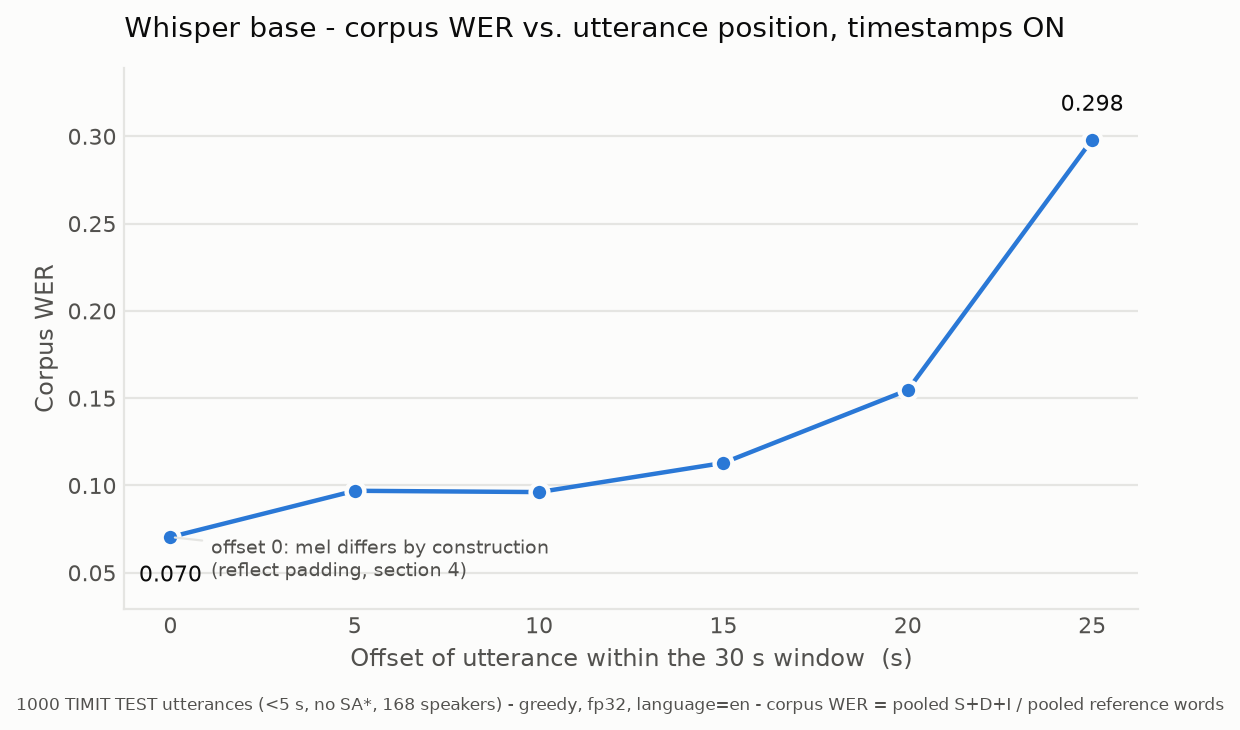

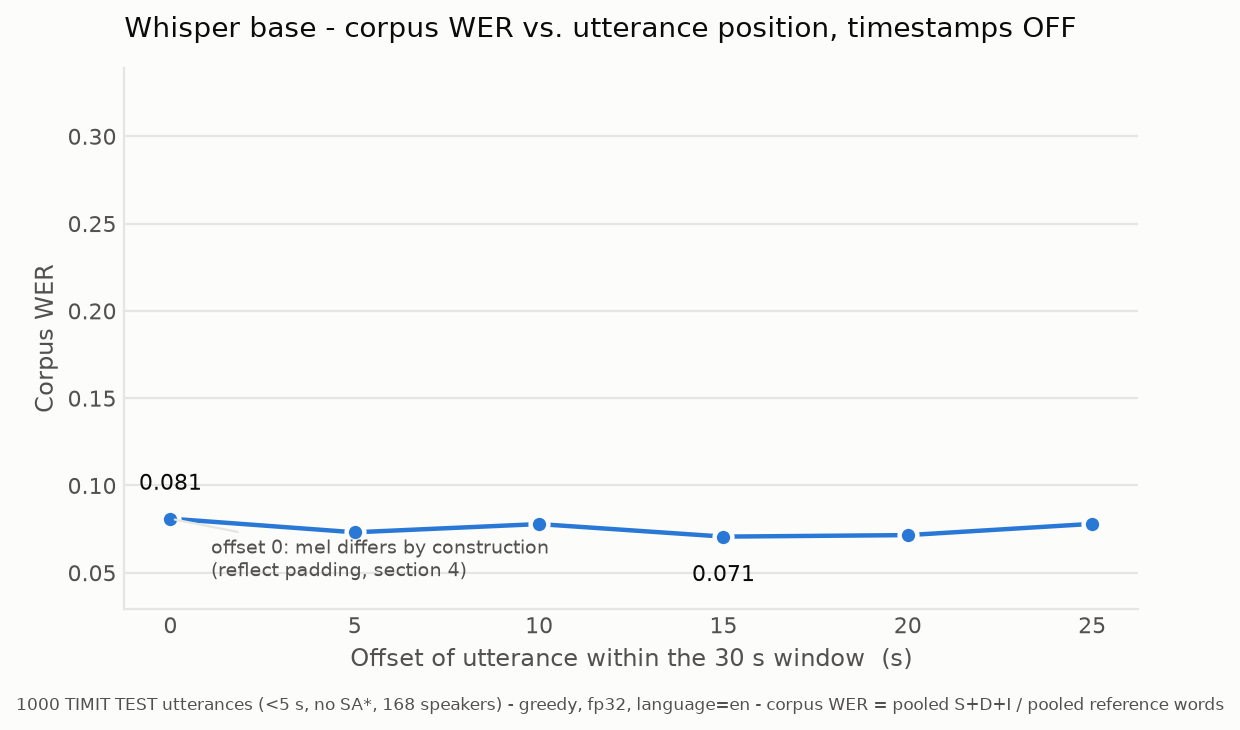

In [7]:
import matplotlib.pyplot as plt

SURFACE, INK, INK2, SERIES, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#2a78d6", "#e5e5e2"

_all = [summary[(ts, s)]["wer"] for ts in ("on", "off") for s in OFFSETS_S]
pad = max((max(_all) - min(_all)) * 0.18, 0.004)
YLIM = (min(_all) - pad, max(_all) + pad)


def plot_arm(ts, fname):
    wers = [summary[(ts, s)]["wer"] for s in OFFSETS_S]
    fig, ax = plt.subplots(figsize=(7.2, 4.4), dpi=160)
    fig.patch.set_facecolor(SURFACE); ax.set_facecolor(SURFACE)

    ax.grid(True, axis="y", color=GRID, linewidth=1, linestyle="-")
    ax.set_axisbelow(True)
    ax.plot(OFFSETS_S, wers, color=SERIES, linewidth=2, marker="o", markersize=8,
            markeredgecolor=SURFACE, markeredgewidth=2,
            solid_capstyle="round", solid_joinstyle="round", zorder=3)

    # selective direct labels: the best and worst offset only -- the table in section 6
    # carries every value
    lo, hi = int(np.argmin(wers)), int(np.argmax(wers))
    for i in {lo, hi}:
        ax.annotate(f"{wers[i]:.3f}", (OFFSETS_S[i], wers[i]),
                    textcoords="offset points", xytext=(0, 13 if i == hi else -20),
                    ha="center", fontsize=10, color=INK)

    ax.set_ylim(*YLIM)
    ax.set_xticks(OFFSETS_S)
    ax.set_xlabel("Offset of utterance within the 30 s window  (s)", fontsize=11, color=INK2)
    ax.set_ylabel("Corpus WER", fontsize=11, color=INK2)
    ax.set_title(f"Whisper base - corpus WER vs. utterance position, timestamps {ts.upper()}",
                 fontsize=12.5, color=INK, pad=14, loc="left")
    ax.tick_params(colors=INK2, labelsize=10, length=0)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(GRID); ax.spines[side].set_linewidth(1)

    ax.annotate("offset 0: mel differs by construction\n(reflect padding, section 4)",
                xy=(0, wers[0]), xytext=(1.1, YLIM[0] + (YLIM[1] - YLIM[0]) * 0.06),
                fontsize=8.5, color=INK2,
                arrowprops=dict(arrowstyle="-", color=GRID, linewidth=1))

    fig.text(0.005, -0.02,
             f"1000 TIMIT TEST utterances (<5 s, no SA*, 168 speakers) - greedy, fp32, "
             f"language=en - corpus WER = pooled S+D+I / pooled reference words",
             fontsize=7.5, color=INK2)
    fig.tight_layout()
    fig.savefig(fname, bbox_inches="tight", facecolor=SURFACE)
    print(f"wrote {fname}")
    return fig


for ts, fn in (("on", "wer_vs_offset_timestamps_on.png"),
               ("off", "wer_vs_offset_timestamps_off.png")):
    plot_arm(ts, fn)
plt.show()

## 8. Verification

The checks from the experiment design, re-run against the finished artefacts so the notebook
fails loudly rather than producing a quietly wrong figure.

In [8]:
ok = []

# 1. manifest integrity
assert len(FILES) == 1000
assert len({r["speaker"] for r in FILES}) == 168
assert not any(r["utt"].startswith("SA") for r in FILES)
assert all(1.0 <= r["sec"] <= 4.975 for r in FILES)
assert all(os.path.exists(os.path.join(TIMIT_TEST, r["path"])) for r in FILES)
ok.append("1. manifest: 1000 files, 168 speakers, no SA*, all <=4.975 s, all present on disk")

# 2. offsets legal
assert all(o % HOP_LENGTH == 0 for o in OFFSETS)
assert all(o + r["samples"] <= N_SAMPLES for r in FILES for o in OFFSETS)
ok.append(f"2. offsets: all multiples of {HOP_LENGTH}, all placements fit in 30 s")

# 3. mel gate (re-assert on a random subset; the full sweep ran in section 4)
_rng = random.Random(7)
for r in _rng.sample(FILES, 40):
    a = AUDIO[r["path"]]
    nf = int(np.ceil(len(a) / HOP_LENGTH)) + 2
    ref = mel_of(a, 5 * SAMPLE_RATE).numpy()
    for s, off in zip(OFFSETS_S[1:], OFFSETS[1:]):
        f0 = s * FRAMES_PER_S
        n = min(nf, N_FRAMES - f0)
        assert np.abs(mel_of(a, off).numpy()[:, f0:f0+n] - ref[:, 500:500+n]).max() == 0.0
ok.append("3. mel gate: offsets 5-25 s bit-identical on a 40-file resample")

# 4. padding is exact zeros
for r in _rng.sample(FILES, 20):
    for off in OFFSETS:
        b = place(AUDIO[r["path"]], off)
        assert np.all(b[:off] == 0) and np.all(b[off + r["samples"]:] == 0)
ok.append("4. padding: buffers are exact zeros outside the utterance")

# 5. determinism -- re-decode a fixed subset and compare to the stored grid
_sub = FILES[:32]
_mel = torch.stack([mel_of(AUDIO[r["path"]], 10 * SAMPLE_RATE) for r in _sub]).to(CONTROLS["device"])
_by = {(r["path"], int(r["offset_s"]), r["timestamps"]): r["text"] for r in rows}
for ts_on in ARMS:
    _o = whisper.DecodingOptions(**BASE_OPTS, without_timestamps=not ts_on)
    for r, res in zip(_sub, whisper.decode(model, _mel, _o)):
        assert res.text == _by[(r["path"], 10, "on" if ts_on else "off")], r["path"]
ok.append("5. determinism: 32-file re-decode reproduces the stored grid byte-for-byte")

# 6. grid completeness
assert len(rows) == len(FILES) * len(OFFSETS_S) * len(ARMS) == 12000
assert len({(r["path"], r["offset_s"], r["timestamps"]) for r in rows}) == 12000
ok.append("6. grid: 12000 rows, no duplicates, no gaps")

# 7. plots
for fn in ("wer_vs_offset_timestamps_on.png", "wer_vs_offset_timestamps_off.png"):
    assert os.path.getsize(fn) > 10000, fn
ok.append("7. figures: both PNGs written")

for line in ok:
    print("PASS  " + line)

PASS  1. manifest: 1000 files, 168 speakers, no SA*, all <=4.975 s, all present on disk
PASS  2. offsets: all multiples of 160, all placements fit in 30 s
PASS  3. mel gate: offsets 5-25 s bit-identical on a 40-file resample
PASS  4. padding: buffers are exact zeros outside the utterance
PASS  5. determinism: 32-file re-decode reproduces the stored grid byte-for-byte
PASS  6. grid: 12000 rows, no duplicates, no gaps
PASS  7. figures: both PNGs written


## 9. Freezing the corpus for future runs

`offset_manifest.json` pins *which* 1000 files this run used, but only as paths into
`/Users/agrfhyl/Documents/timit/TIMIT/TEST`. That is a pointer, not a copy - a later experiment
run after the TIMIT install moves, or on another machine, silently gets a different corpus or
none at all. This section makes the selection self-contained so future results are comparable
to `offset_results.csv` by construction rather than by assumption.

Written under `corpus_frozen/`:

- `audio/DR*/SPKR/UTT.WAV` - byte-for-byte `shutil.copy2` of each source, preserving the exact
  `path` key used in `offset_manifest.json` and `offset_results.csv`. Rows from this run join to
  rows from any future run with no translation step.
- `corpus_manifest.json` - every field of the original manifest plus two digests per file:
  `sha256_file` over the SPHERE bytes, and `sha256_audio` over the decoded float32 samples.
  The second is the one that matters - it pins the array that actually reaches the mel,
  independently of container or decode path.
- provenance - whisper/torch/soundfile versions, the full `CONTROLS` dict, and a digest of
  `offset_results.csv`, so a later run can prove *which* results file it is comparable to.

The `.TXT` transcripts are deliberately **not** copied: `reference` is already carried in the
manifest, so copying them would widen the licensed-data footprint for no gain.

**Licensing.** TIMIT is LDC93S1 - licensed, not redistributable. `corpus_frozen/` is a local
convenience copy, covered by a `.gitignore` rule that the next cell asserts is actually in
effect before writing anything. Do not commit or share the directory.

The cell is resumable and idempotent: a file whose copy already matches its source digest is
not rewritten, so re-running is a fast verification pass rather than a re-copy.

In [ ]:
import hashlib, platform, shutil, subprocess

CORPUS_DIR      = "corpus_frozen"
FROZEN_AUDIO    = os.path.join(CORPUS_DIR, "audio")
FROZEN_MANIFEST = os.path.join(CORPUS_DIR, "corpus_manifest.json")


def sha256_file(path, buf=1 << 20):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(buf), b""):
            h.update(chunk)
    return h.hexdigest()


def sha256_audio(a):
    """Digest of the decoded float32 samples - the array that actually reaches the mel."""
    return hashlib.sha256(np.ascontiguousarray(a, dtype=np.float32).tobytes()).hexdigest()


# refuse to write licensed TIMIT audio into a git-tracked path
_probe = os.path.join(FROZEN_AUDIO, "DR1", "_probe.WAV")
assert subprocess.run(["git", "check-ignore", "-q", _probe]).returncode == 0, (
    f"{CORPUS_DIR}/ is NOT gitignored - refusing to write licensed TIMIT audio into a tracked path"
)

t0, copied, frozen = time.time(), 0, []
for r in FILES:
    src = os.path.join(TIMIT_TEST, r["path"])
    dst = os.path.join(FROZEN_AUDIO, r["path"])
    os.makedirs(os.path.dirname(dst), exist_ok=True)

    h_file = sha256_file(src)
    if not (os.path.exists(dst) and sha256_file(dst) == h_file):   # resumable
        shutil.copy2(src, dst)
        copied += 1

    a, sr = sf.read(dst, dtype="float32")                          # verify through the COPY
    assert sr == SAMPLE_RATE, (r["path"], sr)
    assert len(a) == r["samples"], (r["path"], len(a), r["samples"])
    assert sha256_file(dst) == h_file, f"{r['path']}: copy differs from source bytes"
    assert np.array_equal(a, AUDIO[r["path"]]), f"{r['path']}: copy decodes to a different array"
    frozen.append({**r, "sha256_file": h_file, "sha256_audio": sha256_audio(a)})

provenance = {
    "created":            time.strftime("%Y-%m-%d %H:%M:%S"),
    "corpus":             "TIMIT (LDC93S1) TEST - licensed, NOT redistributable",
    "source_root":        TIMIT_TEST,
    "selection_seed":     manifest["seed"],
    "max_samples":        manifest["max_samples"],
    "n_files":            len(frozen),
    "sample_rate":        SAMPLE_RATE,
    "whisper":            whisper.__version__,
    "torch":              torch.__version__,
    "soundfile":          sf.__version__,
    "python":             platform.python_version(),
    "controls":           CONTROLS,
    "results_csv":        RESULTS_CSV,
    "results_csv_sha256": sha256_file(RESULTS_CSV) if os.path.exists(RESULTS_CSV) else None,
}
os.makedirs(CORPUS_DIR, exist_ok=True)
with open(FROZEN_MANIFEST, "w") as f:
    json.dump({**provenance, "files": frozen}, f, indent=1)

_bytes = sum(os.path.getsize(os.path.join(FROZEN_AUDIO, r["path"])) for r in frozen)
print(f"froze {len(frozen)} clips in {time.time()-t0:.0f}s "
      f"({copied} copied, {len(frozen)-copied} already present and verified)")
print(f"  {FROZEN_AUDIO}/  {_bytes/1e6:.1f} MB")
print(f"  {FROZEN_MANIFEST}")
print(f"  results_csv_sha256 {provenance['results_csv_sha256']}")
print(f"  every clip verified byte-identical to source AND array-identical to this run's AUDIO")

### Using the frozen corpus in a later notebook

`load_frozen()` is the entry point for any follow-up experiment. It needs only `corpus_frozen/`
- no TIMIT install, no `offset_manifest.json`, no path fixups - and re-checks every clip against
its frozen `sha256_audio` on load, so a truncated or altered file fails loudly instead of quietly
shifting a WER number.

Copy the function into the new notebook, or import it from here. To stay comparable to this run,
assert that `results_csv_sha256` in the frozen manifest still matches the `offset_results.csv`
you are comparing against.

The round-trip assertions below prove the frozen copy reproduces *this* run's arrays exactly,
which is what makes a future run's numbers meaningfully comparable to these.

In [ ]:
def load_frozen(corpus_dir=CORPUS_DIR, verify=True):
    """Corpus + audio for a follow-up experiment, with no dependency on the TIMIT install.

    Returns (manifest, {path: float32 array}). With verify=True each clip is checked against
    its frozen sha256_audio, so silent corruption surfaces at load rather than as a WER delta.
    """
    man = json.load(open(os.path.join(corpus_dir, "corpus_manifest.json")))
    audio = {}
    for r in man["files"]:
        a, sr = sf.read(os.path.join(corpus_dir, "audio", r["path"]), dtype="float32")
        if verify:
            assert sr == man["sample_rate"], (r["path"], sr)
            assert len(a) == r["samples"], (r["path"], len(a), r["samples"])
            assert sha256_audio(a) == r["sha256_audio"], f"{r['path']}: does not match frozen digest"
        audio[r["path"]] = a
    return man, audio


_man, _aud = load_frozen()

# the frozen corpus is exactly the corpus this run used
assert {r["path"] for r in _man["files"]} == {r["path"] for r in FILES}
assert all(a["reference"] == b["reference"] for a, b in zip(_man["files"], FILES))
assert all(np.array_equal(_aud[r["path"]], AUDIO[r["path"]]) for r in FILES)

# and it still points at the results file these numbers came from
assert _man["results_csv_sha256"] == sha256_file(RESULTS_CSV), \
    "offset_results.csv changed since the freeze - re-run section 9 before comparing"

print(f"round-trip OK: {len(_aud)} clips reload from {CORPUS_DIR}/ identical to this run")
print(f"  frozen {_man['created']} | whisper {_man['whisper']} | torch {_man['torch']}")
print(f"  comparable to {_man['results_csv']} @ {_man['results_csv_sha256'][:16]}...")
print(f"\nin a future notebook:\n    man, audio = load_frozen()"
      f"\n    # audio['DR1/FAKS0/SI1573.WAV'] -> float32 @ {_man['sample_rate']} Hz")